In [21]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor

california = fetch_california_housing()
X = california.data
y = california.target
feature_names = california.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.3, random_state=42)

#Apply MinMax Scaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#show shapes and feature names for confirmation
X.shape, y.shape, feature_names


((20640, 8),
 (20640,),
 ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'])

In [22]:
from sklearn.metrics import mean_squared_error , r2_score
import numpy as np

#train KNN regressor (we' ll use k=5)
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train_scaled, y_train)

#predict on test data
y_pred = knn_regressor.predict(X_test_scaled)

#Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

rmse, r2

(np.float64(0.6336558663429374), 0.6940895332946582)

In [23]:
#retrain the KNN Regressor with best k=7
best_k = 7
knn_best = KNeighborsRegressor(n_neighbors = best_k)
knn_best.fit(X_train_scaled, y_train)

#predict again using k=7
y_pred_best = knn_best.predict(X_test_scaled)

#evaluate again
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

rmse_best , r2_best

(np.float64(0.6248751158791317), 0.7025089685866329)

#### Residual Analysis - Where is the model Going Wrong?

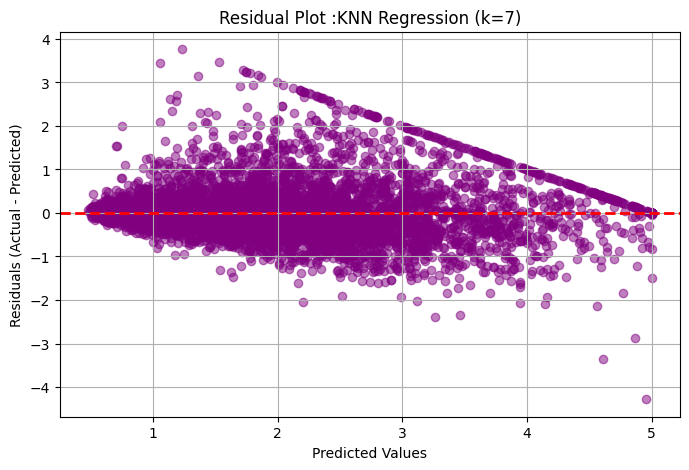

In [26]:
import matplotlib.pyplot as plt
#calculate Residuals
residuals = y_test - y_pred_best

#plot residuals Vs Predicted Values
plt.figure(figsize=(8,5))
plt.scatter(y_pred_best, residuals, color='purple',alpha =0.5)
plt.axhline(y=0,color='red', linestyle='--', linewidth=2)
plt.title("Residual Plot :KNN Regression (k=7)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.grid(True)
plt.show()